In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("penguins.csv")

In [4]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.isna().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [7]:
culmen_length_median=df['culmen_length_mm'].median()

In [8]:
culmen_depth_median=df['culmen_depth_mm'].median()

In [9]:
flipper_length_median=df['flipper_length_mm'].median()

In [10]:
body_mass_median=df['body_mass_g'].median()

In [15]:
sex_mode=df['sex'].mode()
sex_mode

0    MALE
Name: sex, dtype: object

In [17]:
substitute={
    'culmen_length_mm':culmen_length_median,
    'culmen_depth_mm':culmen_depth_median,
    'flipper_length_mm':flipper_length_median,
    'body_mass_g':body_mass_median,
    'sex':sex_mode[0],
}

In [20]:
df.fillna(substitute,inplace=True)

In [21]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.10,18.7,181.0,3750.0,MALE
1,39.50,17.4,186.0,3800.0,FEMALE
2,40.30,18.0,195.0,3250.0,FEMALE
3,44.45,17.3,197.0,4050.0,MALE
4,36.70,19.3,193.0,3450.0,FEMALE


In [22]:
df.isna().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [26]:
penguins_df = pd.get_dummies(df, dtype='int')
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_.,sex_FEMALE,sex_MALE
0,39.10,18.7,181.0,3750.0,0,0,1
1,39.50,17.4,186.0,3800.0,0,1,0
2,40.30,18.0,195.0,3250.0,0,1,0
3,44.45,17.3,197.0,4050.0,0,0,1
4,36.70,19.3,193.0,3450.0,0,1,0


In [30]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(penguins_df)

In [32]:
penguins_df_scaled = pd.DataFrame(
    scaled_data,
    columns=penguins_df.columns
)

In [34]:
penguins_df_scaled.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_.,sex_FEMALE,sex_MALE
0,-0.887622,0.787289,-0.126881,-0.564625,-0.053995,-0.960098,0.965704
1,-0.814037,0.126114,-0.107607,-0.502010,-0.053995,1.041561,-1.035514
2,-0.666866,0.431272,-0.072915,-1.190773,-0.053995,1.041561,-1.035514
3,0.096581,0.075255,-0.065205,-0.188936,-0.053995,-0.960098,0.965704
4,-1.329133,1.092447,-0.080624,-0.940314,-0.053995,1.041561,-1.035514


In [37]:
pca=PCA(n_components=2)

In [38]:
pca_data=pca.fit_transform(penguins_df_scaled)

In [40]:
pca_data

array([[-0.57664147,  1.65464398],
       [ 1.71903293,  0.10651734],
       [ 1.92745815,  0.59308441],
       [-1.06513333,  0.60324258],
       [ 2.02674683,  1.18689859],
       [-0.61555127,  2.37217803],
       [ 1.83991032,  0.39452907],
       [-1.11326276,  1.41176864],
       [-0.05412445,  1.96508785],
       [-2.3366305 ,  2.44212025],
       [-0.18338857,  1.45356152],
       [-0.40178273,  1.28295318],
       [ 1.91617473,  0.42313277],
       [-0.66925953,  2.54362562],
       [-0.61607717,  2.38083591],
       [ 1.96291693,  0.51344997],
       [ 1.89572441,  0.9393637 ],
       [-1.29964419,  1.67088387],
       [ 2.29476614,  1.10637224],
       [-1.42084405,  1.88423928],
       [ 2.01943297,  0.78303193],
       [-0.39720085,  1.84397958],
       [ 1.9032073 ,  0.99761278],
       [-0.5957697 ,  1.38742395],
       [-0.52202   ,  1.11661298],
       [ 1.95834193,  0.93407227],
       [-0.57399912,  1.63327279],
       [ 1.94572282,  0.57236259],
       [ 2.13341584,

C:\Users\nihar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nihar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nihar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\nihar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

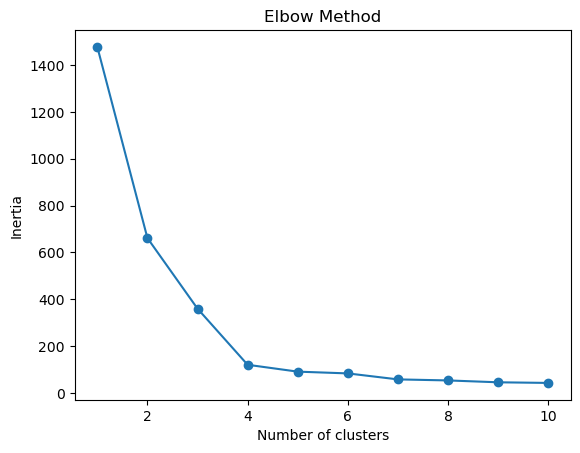

In [46]:
inertia=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42).fit(pca_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11),inertia,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [47]:
no_of_clusters=4

In [48]:
kmeans=KMeans(n_clusters=no_of_clusters,init="k-means++",random_state=0)
y=kmeans.fit_predict(pca_data)
y

C:\Users\nihar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([2, 3, 3, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 3, 3, 2, 3, 2, 3, 2,
       3, 2, 2, 3, 2, 3, 3, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 3, 2, 3, 2,
       3, 2, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 2, 3,
       2, 3, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 3, 2, 3, 2,
       2, 3, 2, 3, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 2, 0, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 2, 0, 3, 2, 3, 2, 2, 3, 2, 3, 3, 2,
       3, 2, 2, 3, 3, 2, 3, 2, 3, 2, 3, 2, 2, 3, 2, 3, 3, 2, 3, 2, 2, 3,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,

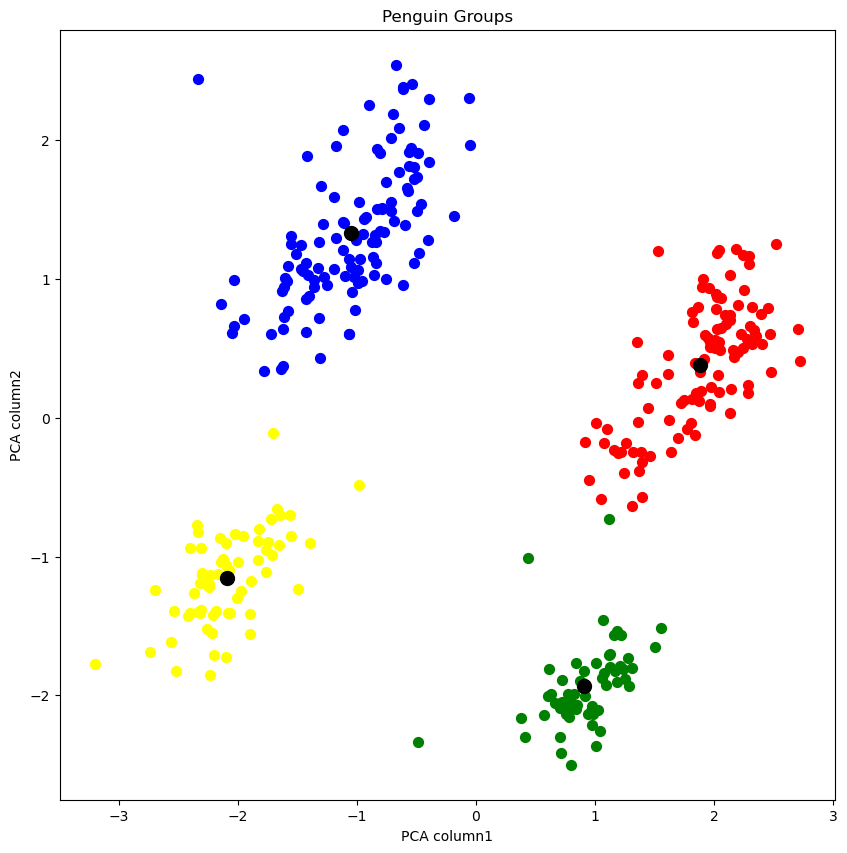

In [52]:
# plotting all the clusters and their Centroids

plt.figure(figsize=(10,10))
plt.scatter(pca_data[y==0,0],pca_data[y==0,1],s=50,c='green',label='Cluster 1')
plt.scatter(pca_data[y==1,0],pca_data[y==1,1],s=50,c='yellow',label='Cluster 2')
plt.scatter(pca_data[y==2,0],pca_data[y==2,1],s=50,c='blue',label='Cluster 3')
plt.scatter(pca_data[y==3,0],pca_data[y==3,1],s=50,c='red',label='Cluster 4')

# plot the centroids

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=100,c='black',label='Centroids')

plt.title('Penguin Groups')
plt.xlabel('PCA column1')
plt.ylabel('PCA column2')
plt.show()

C:\Users\nihar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


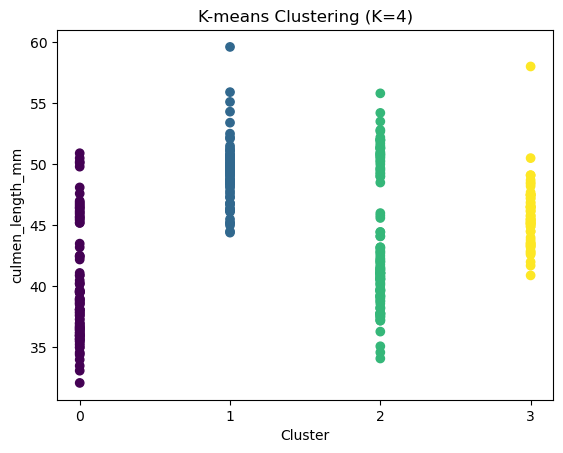

In [57]:
#Another way

kmeans = KMeans(n_clusters=no_of_clusters, random_state=42).fit(pca_data)
x = kmeans.labels_

# and visualize the clusters (here for the 'culmen_length_mm' column)
plt.scatter(x, penguins_df['culmen_length_mm'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('Cluster')
plt.ylabel('culmen_length_mm')
plt.xticks(range(int(x.min()), int(x.max()) + 1))
plt.title(f'K-means Clustering (K={no_of_clusters})')
plt.show()